In [1]:
# Import Necesasry Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Data Loading

In [2]:
# Load data
df=pd.read_csv('/kaggle/input/healthcare-prediction-dataset/healthcare_prediction_dataset.csv')

In [3]:
# Sample Data
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


# Initial data analysis

In [4]:
print("Data Summary:")
df.info()

Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
mem

In [5]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [6]:
# Data Cleaning: Drop unwanted columns
df.drop(['Name', 'Doctor', 'Hospital', 'Discharge Date'], axis=1, inplace=True)

# EDA

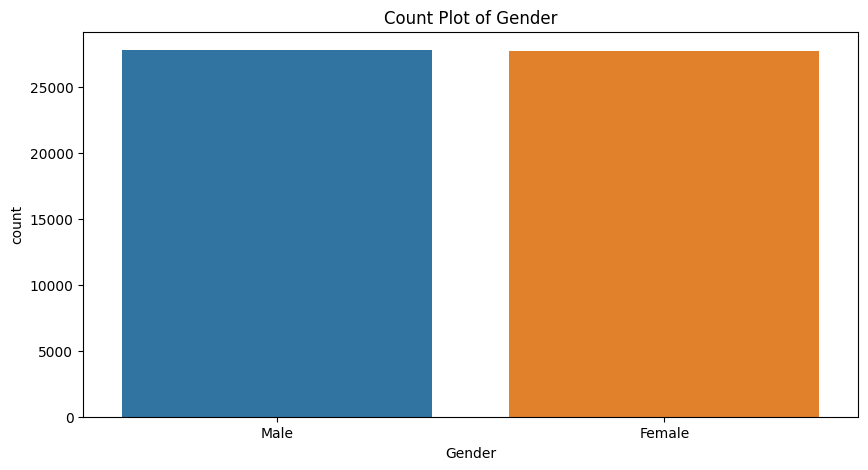

In [7]:
# EDA: Categorical count plot
plt.figure(figsize=(10, 5))
sns.countplot(x='Gender', data=df)
plt.title('Count Plot of Gender')
plt.show()

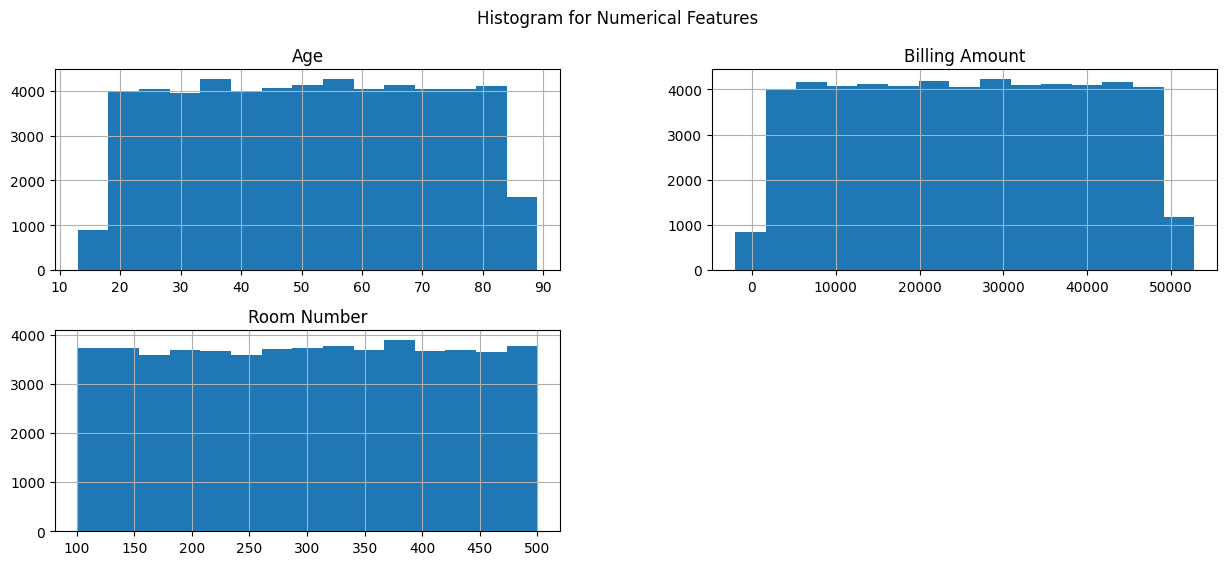

In [8]:
# EDA: Histogram for numerical columns
df[['Age', 'Billing Amount', 'Room Number']].hist(bins=15, figsize=(15, 6))
plt.suptitle('Histogram for Numerical Features')
plt.show()


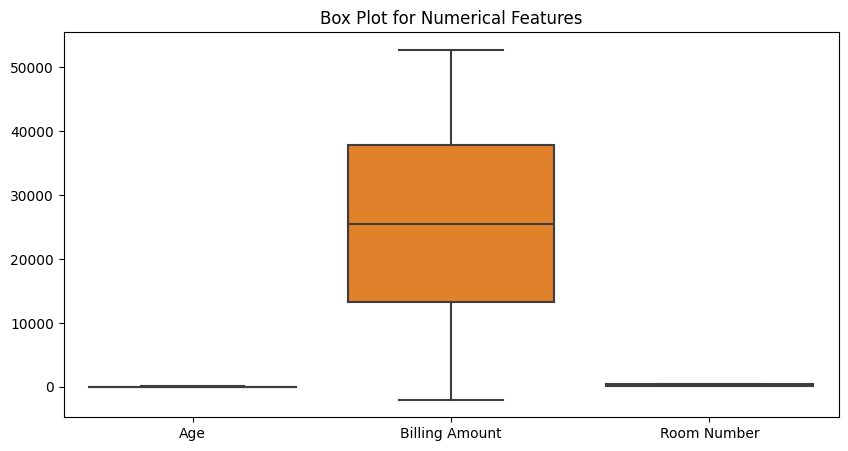

In [9]:
# EDA: Box plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Age', 'Billing Amount', 'Room Number']])
plt.title('Box Plot for Numerical Features')
plt.show()

# Data Preprocessing

In [10]:
# Identify categorical columns
categorical_columns = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']

# Finding unique values in each categorical column
for col in categorical_columns:
    unique_values = df[col].unique()
    print(f"Unique values in '{col}': {unique_values}")

Unique values in 'Gender': ['Male' 'Female']
Unique values in 'Blood Type': ['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']
Unique values in 'Medical Condition': ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']
Unique values in 'Insurance Provider': ['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']
Unique values in 'Admission Type': ['Urgent' 'Emergency' 'Elective']
Unique values in 'Medication': ['Paracetamol' 'Ibuprofen' 'Aspirin' 'Penicillin' 'Lipitor']
Unique values in 'Test Results': ['Normal' 'Inconclusive' 'Abnormal']


In [11]:
# Manual mapping for categorical columns
mappings = {
    'Gender': {'Male': 0, 'Female': 1},
    'Blood Type': {'B-': 0, 'A+': 1, 'A-': 2, 'O+': 3, 'AB+': 4, 'AB-': 5, 'B+': 6, 'O-': 7},
    'Medical Condition': {'Cancer': 0, 'Obesity': 1, 'Diabetes': 2, 'Asthma': 3, 'Hypertension': 4, 'Arthritis': 5},
    'Insurance Provider': {'Blue Cross': 0, 'Medicare': 1, 'Aetna': 2, 'UnitedHealthcare': 3, 'Cigna': 4},
    'Admission Type': {'Urgent': 0, 'Emergency': 1, 'Elective': 2},
    'Medication': {'Paracetamol': 0, 'Ibuprofen': 1, 'Aspirin': 2, 'Penicillin': 3, 'Lipitor': 4},
    'Test Results': {'Normal': 0, 'Inconclusive': 1, 'Abnormal': 2}
}

# Applying the mappings to the DataFrame
for col, mapping in mappings.items():
    df[col] = df[col].map(mapping)

# Display the DataFrame after encoding
df

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Room Number,Admission Type,Medication,Test Results
0,30,0,0,0,2024-01-31,0,18856.281306,328,0,0,0
1,62,0,1,1,2019-08-20,1,33643.327287,265,1,1,1
2,76,1,2,1,2022-09-22,2,27955.096079,205,1,2,0
3,28,1,3,2,2020-11-18,1,37909.782410,450,2,1,2
4,43,1,4,0,2022-09-19,2,14238.317814,458,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...
55495,42,1,3,3,2020-08-16,0,2650.714952,417,2,3,2
55496,61,1,5,1,2020-01-23,4,31457.797307,316,2,2,0
55497,38,1,6,4,2020-07-13,3,27620.764717,347,0,1,2
55498,43,0,7,5,2019-05-25,1,32451.092358,321,2,1,2


In [12]:
# Convert 'Date of Admission' to datetime format
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])

# Extract year, month, and day into separate columns
df['Admission Year'] = df['Date of Admission'].dt.year
df['Admission Month'] = df['Date of Admission'].dt.month
df['Admission Day'] = df['Date of Admission'].dt.day

# Drop the original 'Date of Admission' column
df.drop('Date of Admission', axis=1, inplace=True)

In [13]:
# Sample DF
df

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Room Number,Admission Type,Medication,Test Results,Admission Year,Admission Month,Admission Day
0,30,0,0,0,0,18856.281306,328,0,0,0,2024,1,31
1,62,0,1,1,1,33643.327287,265,1,1,1,2019,8,20
2,76,1,2,1,2,27955.096079,205,1,2,0,2022,9,22
3,28,1,3,2,1,37909.782410,450,2,1,2,2020,11,18
4,43,1,4,0,2,14238.317814,458,0,3,2,2022,9,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,42,1,3,3,0,2650.714952,417,2,3,2,2020,8,16
55496,61,1,5,1,4,31457.797307,316,2,2,0,2020,1,23
55497,38,1,6,4,3,27620.764717,347,0,1,2,2020,7,13
55498,43,0,7,5,1,32451.092358,321,2,1,2,2019,5,25


In [14]:
# Separating features (X) and target (y)
X = df.drop('Medical Condition', axis=1)  # Features
y = df['Test Results']  # Target

X.shape, y.shape

((55500, 12), (55500,))

In [15]:
# Data Preprocessing: Feature scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

In [16]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model Traning

In [17]:
# Classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Training and evaluation
results = []
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    results.append({
        'Classifier': name,
        'Accuracy': accuracy,
        'Recall': recall,
        'F1 Score': f1,
        'Precision': precision
    })
    print(f"\n{name}:\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(cm)

# Creating a results DataFrame
results_df = pd.DataFrame(results)
print("\nResults Summary:")
print(results_df)


Logistic Regression:

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.38      0.36      5589
           1       0.34      0.16      0.22      5418
           2       0.34      0.47      0.40      5643

    accuracy                           0.34     16650
   macro avg       0.34      0.34      0.33     16650
weighted avg       0.34      0.34      0.33     16650

Confusion Matrix:
[[2125  866 2598]
 [1997  892 2529]
 [2108  867 2668]]

Random Forest:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5589
           1       1.00      1.00      1.00      5418
           2       1.00      1.00      1.00      5643

    accuracy                           1.00     16650
   macro avg       1.00      1.00      1.00     16650
weighted avg       1.00      1.00      1.00     16650

Confusion Matrix:
[[5589    0    0]
 [   0 5418    0]
 [   0    0 5643]]

Decis

/tmp/ipykernel_30/2659573367.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0, 0].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')
/tmp/ipykernel_30/2659573367.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0, 1].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')
/tmp/ipykernel_30/2659573367.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1, 0].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')
/tmp/ipykernel_30/2659573367.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1, 1].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')


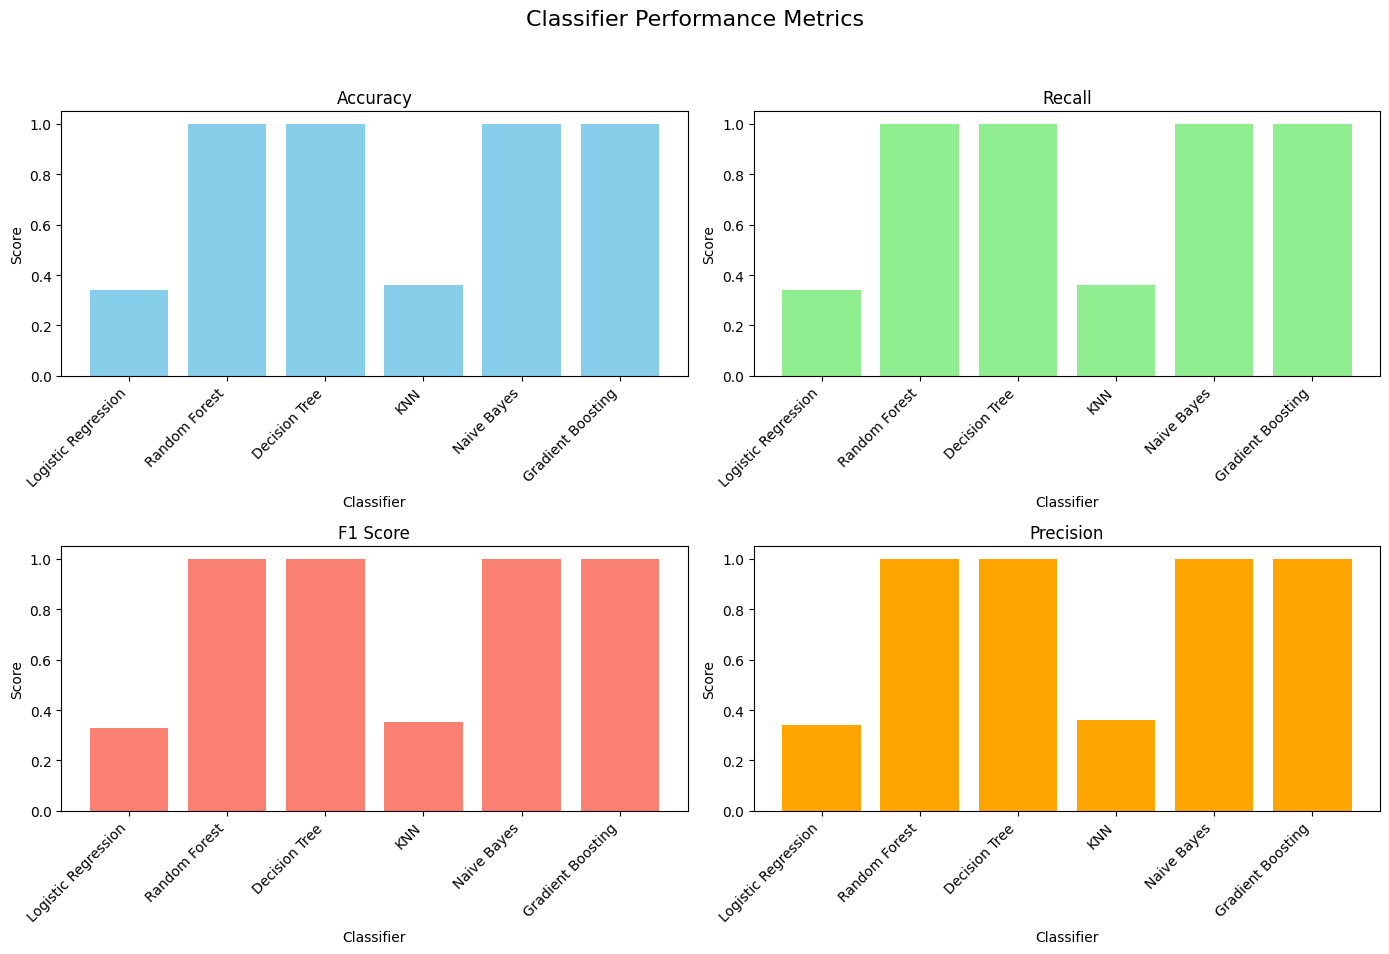

In [18]:
# Creating subplots for each metric
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Classifier Performance Metrics', fontsize=16)

# Accuracy plot
ax[0, 0].bar(results_df['Classifier'], results_df['Accuracy'], color='skyblue')
ax[0, 0].set_title('Accuracy')
ax[0, 0].set_xlabel('Classifier')
ax[0, 0].set_ylabel('Score')
ax[0, 0].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')

# Recall plot
ax[0, 1].bar(results_df['Classifier'], results_df['Recall'], color='lightgreen')
ax[0, 1].set_title('Recall')
ax[0, 1].set_xlabel('Classifier')
ax[0, 1].set_ylabel('Score')
ax[0, 1].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')

# F1 Score plot
ax[1, 0].bar(results_df['Classifier'], results_df['F1 Score'], color='salmon')
ax[1, 0].set_title('F1 Score')
ax[1, 0].set_xlabel('Classifier')
ax[1, 0].set_ylabel('Score')
ax[1, 0].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')

# Precision plot
ax[1, 1].bar(results_df['Classifier'], results_df['Precision'], color='orange')
ax[1, 1].set_title('Precision')
ax[1, 1].set_xlabel('Classifier')
ax[1, 1].set_ylabel('Score')
ax[1, 1].set_xticklabels(results_df['Classifier'], rotation=45, ha='right')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [19]:
# Define individual models
random_forest = RandomForestClassifier()
decision_tree = DecisionTreeClassifier()
gradient_boosting = GradientBoostingClassifier()

# Create a voting classifier with soft voting
ensemble_model = VotingClassifier(
    estimators=[
        ('Random Forest', random_forest),
        ('Decision Tree', decision_tree),
        ('Gradient Boosting', gradient_boosting)
    ],
    voting='soft'  # Soft voting to average the probability of predictions
)

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Predict on test data
y_pred_ensemble = ensemble_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_ensemble)
recall = recall_score(y_test, y_pred_ensemble, average='weighted')
f1 = f1_score(y_test, y_pred_ensemble, average='weighted')
precision = precision_score(y_test, y_pred_ensemble, average='weighted')
cm = confusion_matrix(y_test, y_pred_ensemble)

print("Ensemble Model (Voting Classifier):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble))

Ensemble Model (Voting Classifier):
Accuracy: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Confusion Matrix:
[[5589    0    0]
 [   0 5418    0]
 [   0    0 5643]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5589
           1       1.00      1.00      1.00      5418
           2       1.00      1.00      1.00      5643

    accuracy                           1.00     16650
   macro avg       1.00      1.00      1.00     16650
weighted avg       1.00      1.00      1.00     16650



In [20]:
# Define file paths for saving
scaler_filename = "scaler.pkl"
voting_model_filename = "voting_classifier.pkl"

# Save the scaler
with open(scaler_filename, 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

# Save the ensemble voting classifier model
with open(voting_model_filename, 'wb') as model_file:
    pickle.dump(ensemble_model, model_file)

print(f"Scaler saved as '{scaler_filename}' and Voting Classifier saved as '{voting_model_filename}'")

Scaler saved as 'scaler.pkl' and Voting Classifier saved as 'voting_classifier.pkl'
